In [1]:
import torch
import numpy as np
from torch import Tensor
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from src.plotting import plt_sample
from src.configs import TrainingConfig, DatasetConfig, DEVICE
from src.dataset import get_data_loaders, load_preprocessed_dataset

In [ ]:
train_cfg = TrainingConfig(batch_size=10)
x_train, y_train, x_test = load_preprocessed_dataset()

In [40]:
from torchvision.transforms import v2
dataset_cfg = DatasetConfig(transform=v2.Compose([
        v2.RandomErasing(p=0.3, scale=(0.05, 0.1)),
        v2.RandomErasing(p=0.3, scale=(0.05, 0.1)),
        v2.RandomErasing(p=0.3, scale=(0.05, 0.1)),
        v2.RandomErasing(p=0.3, scale=(0.05, 0.1)),
        v2.RandomErasing(p=0.3, scale=(0.05, 0.1)),
        v2.RandomErasing(p=0.3, scale=(0.05, 0.1)),
        v2.RandomErasing(p=0.3, scale=(0.05, 0.1)),
        v2.RandomErasing(p=0.3, scale=(0.05, 0.1)),
        v2.RandomAffine(degrees=(0, 0), translate=(0.1, 0.3), scale=(0.75, 1)),
    ]))
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=dataset_cfg.test_size,
    random_state=train_cfg.random_state,
)
train_loader, valid_loader = get_data_loaders(
    x_train,
    y_train,
    x_valid,
    y_valid,
    train_cfg=train_cfg,
)

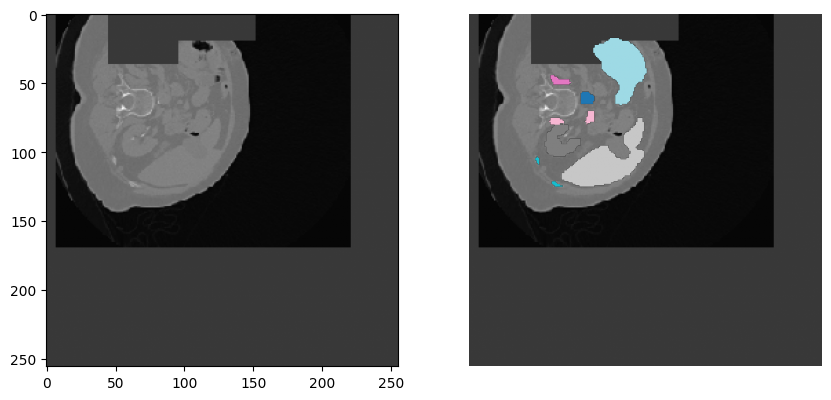

In [53]:
from torchvision.tv_tensors import Mask

batch_x, batch_y = next(iter(train_loader))
batch_x_, batch_y_ = dataset_cfg.transform(batch_x, Mask(batch_y))
batch_x_, batch_y_ = batch_x_.cpu().numpy(), batch_y_.cpu().numpy()
plt_sample(batch_x_[0, 0], batch_y_[0])
# for x, y in zip(batch_x_, batch_y_):
    # plt_sample(x[0], y)